# Teclo Customer Churm Prediction

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df = pd.read_csv("Customer Churn.csv")
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [9]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


# Converting Datatype of object where the data is encoding 

In [6]:
df['TotalCharges'] = df['TotalCharges'].replace(" ","0")
df['TotalCharges'] = df['TotalCharges'].astype(float)

In [11]:
df.duplicated().sum()  

0

In [12]:
df['customerID'].duplicated().sum()

0

In [13]:
# converted the 0 to 1 value of senior citizen to yes/no to make its easier to understand
def conv(value):
    if value == 1:
        return 'yes'
    else:
        return 'no'

df['SeniorCitizen'] = df['SeniorCitizen'].apply(conv)

In [14]:
df['SeniorCitizen'].unique()

array(['no', 'yes'], dtype=object)

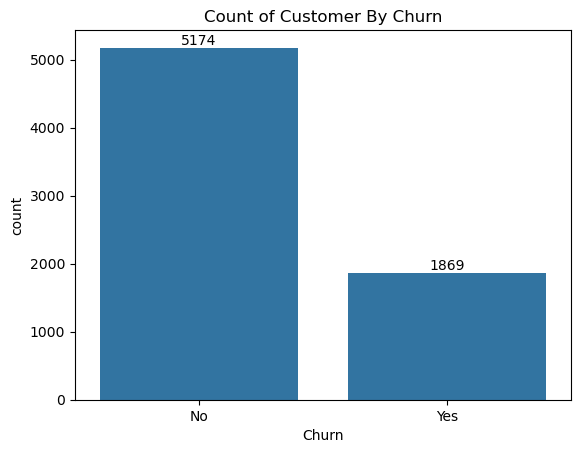

In [24]:
ax = sns.countplot(x = 'Churn', data = df)
ax.bar_label(ax.containers[0]) # its show the count to conatiner show
plt.title('Count of Customer By Churn')
plt.show()

In [ ]:
# checking percentage value of churn

In [19]:
gb = df.groupby('Churn').agg({'Churn':'count'})
gb

,Churn
Churn,
No,5174
Yes,1869


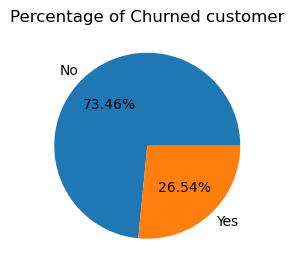

In [27]:
plt.figure(figsize=(3,4))
plt.pie(gb['Churn'], labels = gb.index, autopct = '%1.2f%%')
plt.title("Percentage of Churned customer")
plt.show()

In [28]:
# from the given pie chart we calaculate that 26.54% people or leave the or churn out customer 


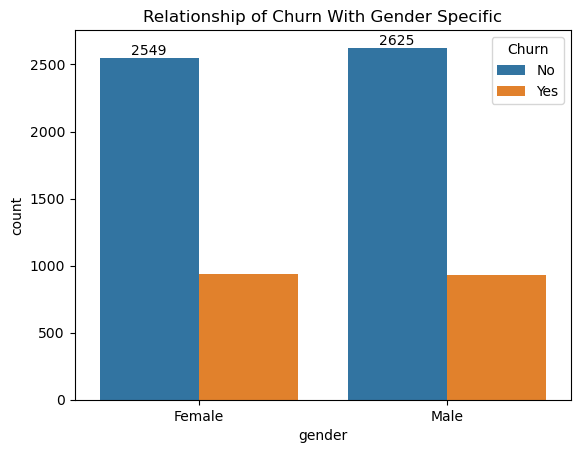

In [33]:
ax = sns.countplot(x = 'gender', data = df, hue = 'Churn')
ax.bar_label(ax.containers[0])
plt.title("Relationship of Churn With Gender Specific")
plt.show()

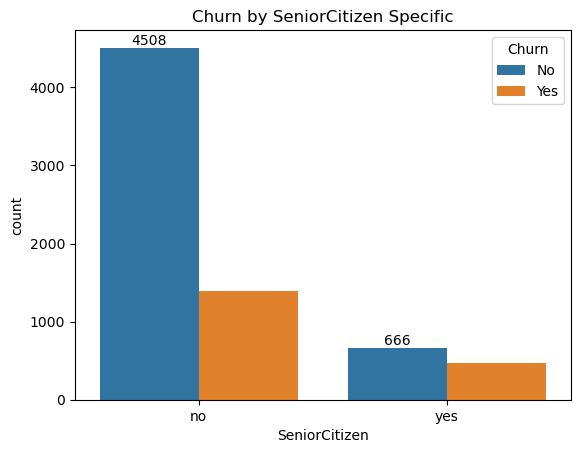

In [34]:
ax = sns.countplot(x = 'SeniorCitizen', data = df, hue = 'Churn')
ax.bar_label(ax.containers[0])
plt.title("Churn by SeniorCitizen Specific")
plt.show()

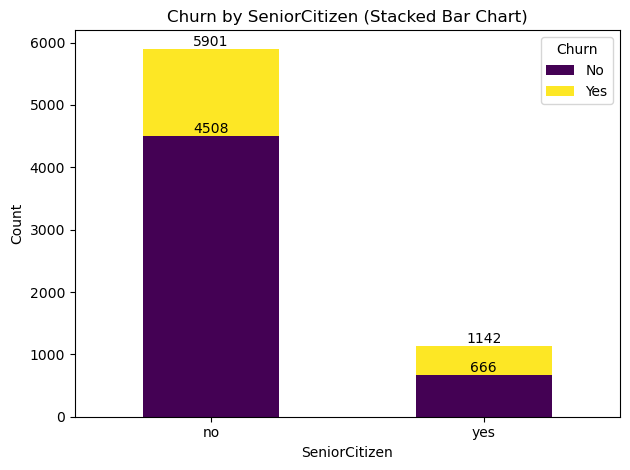

In [35]:
# Crosstab create karo
cross_tab = pd.crosstab(df['SeniorCitizen'], df['Churn'])

# Stacked bar plot
ax = cross_tab.plot(kind='bar', stacked=True, colormap='viridis')
plt.title("Churn by SeniorCitizen (Stacked Bar Chart)")
plt.xlabel("SeniorCitizen")
plt.ylabel("Count")
plt.legend(title='Churn')
plt.xticks(rotation=0)

# Bar labels
for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

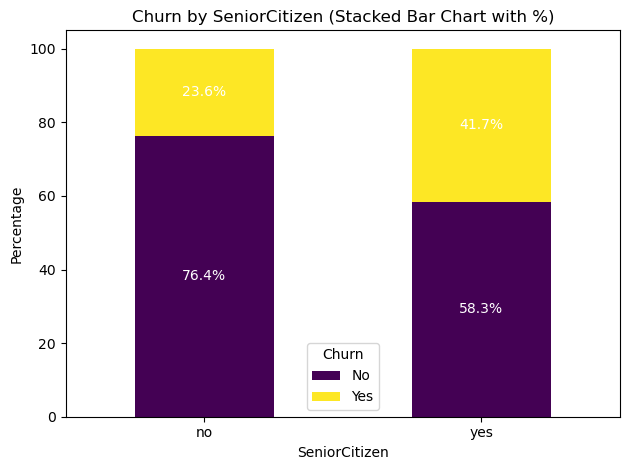

In [36]:
# Crosstab with normalize for percentage by row
cross_tab = pd.crosstab(df['SeniorCitizen'], df['Churn'], normalize='index') * 100

# Plot
ax = cross_tab.plot(kind='bar', stacked=True, colormap='viridis')
plt.title("Churn by SeniorCitizen (Stacked Bar Chart with %)")
plt.xlabel("SeniorCitizen")
plt.ylabel("Percentage")
plt.legend(title='Churn')
plt.xticks(rotation=0)

# Add percentage labels
for i in range(len(cross_tab)):
    total = 0
    for j, value in enumerate(cross_tab.iloc[i]):
        total += value
        ax.text(i, total - value / 2, f"{value:.1f}%", ha='center', va='center', color='white', fontsize=10)

plt.tight_layout()
plt.show()

#comparative a grater percentage of of people in senior citizen category have churned

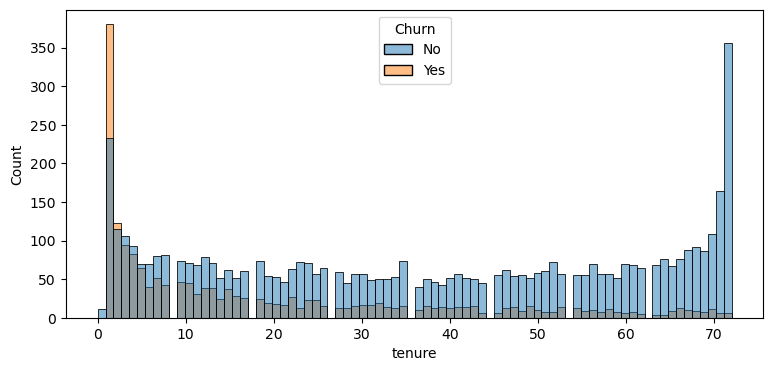

In [42]:
plt.figure(figsize=(9,4))
sns.histplot(x = 'tenure', data = df, bins = 80, hue = 'Churn')
plt.show()

#people who have used our service for a long time have staye and who have used our service #1 to 2 monthshave chunned

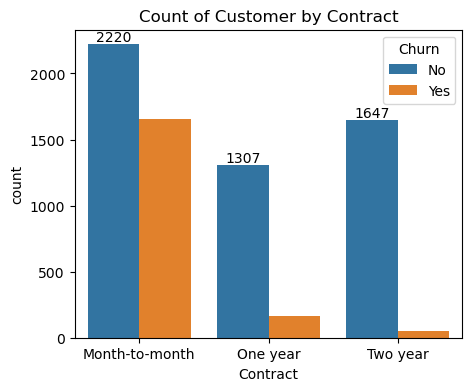

In [46]:
plt.figure(figsize=(5,4))
ax = sns.countplot(x = 'Contract', data = df, hue = 'Churn')
ax.bar_label(ax.containers[0])
plt.title("Count of Customer by Contract")
plt.show()

#PEOPLE who have month to month contract are likely to churn them from those whow have 1 or 2 yeatrs cntract

In [47]:
df.columns.values

array(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn'], dtype=object)

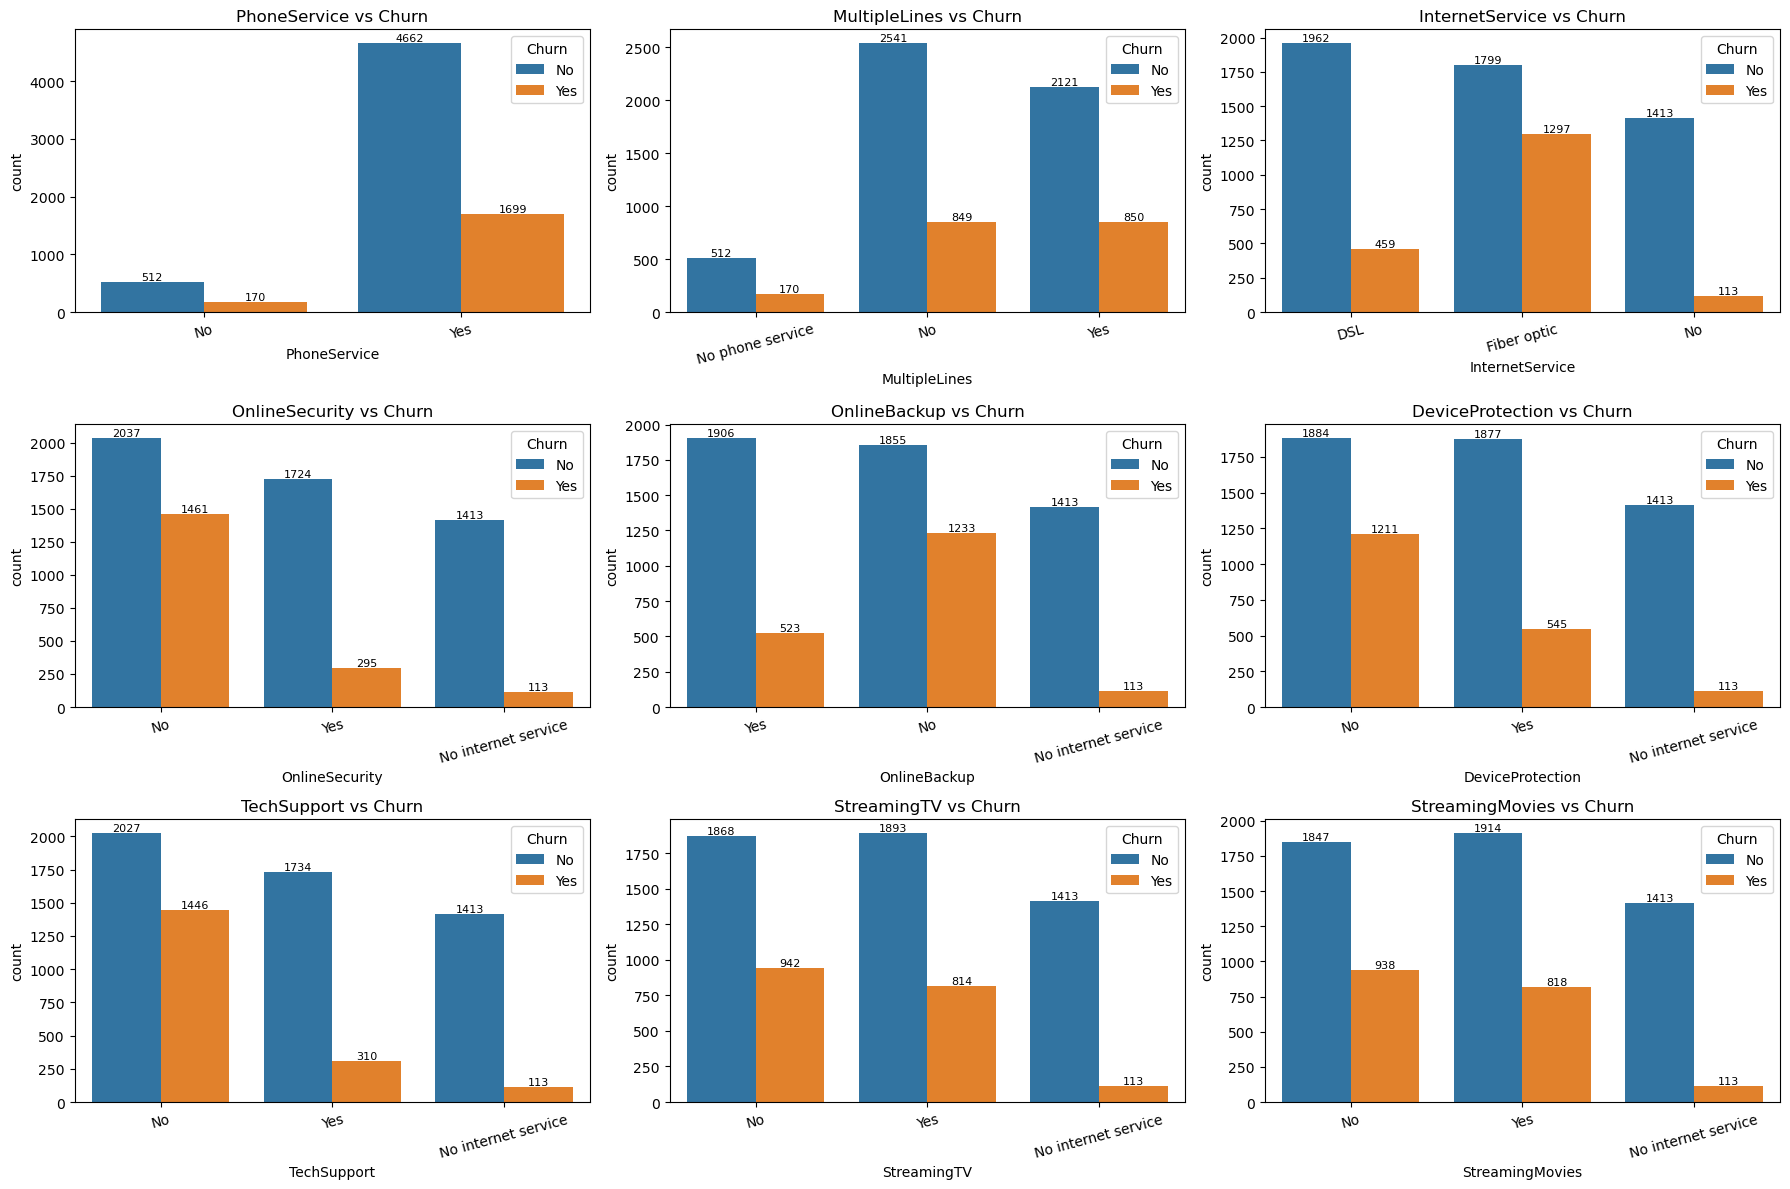

In [48]:
# Columns list
cols = ['PhoneService', 'MultipleLines', 'InternetService',
        'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
        'TechSupport', 'StreamingTV', 'StreamingMovies']

# Subplot grid size
n_cols = 3
n_rows = (len(cols) + n_cols - 1) // n_cols

plt.figure(figsize=(18, n_rows * 4))  # Adjust figure size as needed

# Loop through each column and plot
for i, col in enumerate(cols, 1):
    plt.subplot(n_rows, n_cols, i)
    ax = sns.countplot(x=col, data=df, hue='Churn')
    plt.title(f"{col} vs Churn")
    plt.xticks(rotation=15)
    # Add count labels
    for container in ax.containers:
        ax.bar_label(container, fontsize=8)

plt.tight_layout()
plt.show()


#🔸 Customers without security/support services (like OnlineSecurity, Backup, TechSupport) tend to churn more.
🔸 Fiber optic internet users show higher churn than DSL — maybe due to unmet expectations.
🔸 Streaming services (TV, Movies) don't significantly affect churn — not sticky enough.
🔸 Extra services = more customer stickiness, basic services alone aren’t enough to prevent churn.

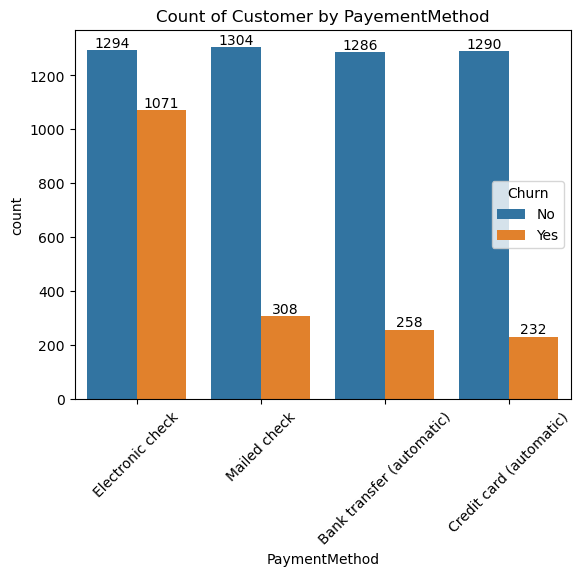

In [56]:
#plt.figure(figsize=(6,4))
ax = sns.countplot(x = 'PaymentMethod', data = df, hue = 'Churn')
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title("Count of Customer by PayementMethod")
plt.xticks(rotation = 45)
plt.show()

#customer is likely to churn when he is using electronic check as payement method